# DNSC 6330 — Individual Homework: Python Coding Audit

**Title:** From Accuracy to Accountability: Stress Testing a Predictive Model

It evaluates:
- distribution drift
- generalization
- spurious-correlation probes
- robustness
- slice-based subgroup evaluation


## AI Acknowledgement

I used a generative AI tool (Claude) for help with debugging the code, sanity checking outputs, and confirming that what I had implemented matched what the assignment required.

## Setup from earlier lectures

These cells only set up the COMPAS data, target, train/test split, and the two models used by the Lecture 04 section.


In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import pandas as pd

# Load the ProPublica COMPAS two-year recidivism dataset directly from GitHub
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)

# Quick sanity check: number of raw rows before any filtering
raw_data.shape[0]

7214

In [2]:
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


In [3]:
import pandas as pd
import numpy as np

# Variable groupings used for type handling below
numeric_vars = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]

# Keep only the columns needed downstream
df = raw_data[[
    "age", "c_charge_degree", "race", "age_cat",
    "score_text", "sex", "priors_count",
    "days_b_screening_arrest", "decile_score", "is_recid",
    "two_year_recid", "c_jail_in", "c_jail_out"
]].copy()

# Standard ProPublica filtering: keep records within 30 days of arrest, drop
# unknown recidivism status, drop "ordinary traffic offense" and missing scores
df = df[
    (df["days_b_screening_arrest"].between(-30, 30)) &
    (df["is_recid"] != -1) &
    (df["c_charge_degree"] != "O") &
    (df["score_text"] != "N/A")
]

# Type conversions
# Parse jail-in / jail-out as UTC datetimes
for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], format="%Y-%m-%d %H:%M:%S", utc=True)

# Anything that's not numeric and not datetime becomes a categorical column
for col in df.columns:
    if col not in numeric_vars + datetime_vars:
        df[col] = df[col].astype("category")

# Derived factors with explicit reference levels (first category = reference)

# crime_factor: misdemeanor vs felony charge
df["crime_factor"] = df["c_charge_degree"].astype("category")

# age_factor: reorder so "25 - 45" is the reference category
df["age_factor"] = pd.Categorical(
    df["age_cat"],
    categories=["25 - 45"] + [c for c in df["age_cat"].unique() if c != "25 - 45"],
    ordered=False
)

# race_factor: reorder so "Caucasian" is the reference category
df["race_factor"] = pd.Categorical(
    df["race"],
    categories=["Caucasian"] + [c for c in df["race"].unique() if c != "Caucasian"],
    ordered=False
)

# gender_factor: relabel + set "Male" as reference category
df["gender_factor"] = df["sex"].map({
    "Female": "Female",
    "Male": "Male"
}).astype("category")

df["gender_factor"] = pd.Categorical(
    df["gender_factor"],
    categories=["Male", "Female"],  # reference first
    ordered=False
)

# score_factor: collapse 3-level COMPAS score into binary High/Low
df["score_factor"] = pd.Categorical(
    np.where(df["score_text"] != "Low", "HighScore", "LowScore"),
    categories=["LowScore", "HighScore"],
    ordered=False
)

# Row count after filtering and factor construction
df.shape[0]

6172

In [4]:
df.head(10)

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,Male,LowScore
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,Male,LowScore
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,Male,HighScore
7,43,F,Other,25 - 45,Low,Male,3,-1.0,4,0,0,2013-08-29 08:55:23+00:00,2013-08-30 08:42:13+00:00,F,25 - 45,Other,Male,LowScore
8,39,M,Caucasian,25 - 45,Low,Female,0,-1.0,1,0,0,2014-03-15 05:35:34+00:00,2014-03-18 04:28:46+00:00,M,25 - 45,Caucasian,Female,LowScore
10,27,F,Caucasian,25 - 45,Low,Male,0,-1.0,4,0,0,2013-11-25 06:31:06+00:00,2013-11-26 08:26:57+00:00,F,25 - 45,Caucasian,Male,LowScore
11,23,M,African-American,Less than 25,Medium,Male,3,0.0,6,1,1,2013-10-03 04:07:35+00:00,2013-10-07 08:17:30+00:00,M,Less than 25,African-American,Male,HighScore
12,37,M,Caucasian,25 - 45,Low,Female,0,0.0,1,0,0,2013-01-01 03:28:03+00:00,2013-01-02 01:12:19+00:00,M,25 - 45,Caucasian,Female,LowScore


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   age                      6172 non-null   int64              
 1   c_charge_degree          6172 non-null   category           
 2   race                     6172 non-null   category           
 3   age_cat                  6172 non-null   category           
 4   score_text               6172 non-null   category           
 5   sex                      6172 non-null   category           
 6   priors_count             6172 non-null   int64              
 7   days_b_screening_arrest  6172 non-null   float64            
 8   decile_score             6172 non-null   int64              
 9   is_recid                 6172 non-null   category           
 10  two_year_recid           6172 non-null   category           
 11  c_jail_in                6172 non-n

In [6]:
import statsmodels.formula.api as smf

# Convert score_factor into a 0/1 binary target for the logistic regression
df["score_binary"] = (df["score_factor"] == "HighScore").astype(int)

# Fit a logistic regression with R-style formula syntax via statsmodels.
# C(...) wraps each categorical so statsmodels uses dummy encoding with
# the reference level we set above.
model_glm = smf.logit(
    formula="""
    score_binary ~
    C(gender_factor) +
    C(age_factor) +
    C(race_factor) +
    priors_count +
    C(crime_factor) +
    two_year_recid
    """,
    data=df
).fit()

print(model_glm.summary())

Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           score_binary   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Wed, 29 Apr 2026   Pseudo R-squ.:                  0.2729
Time:                        05:26:43   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                             -1.5255      0.079    

In [7]:
from sklearn.model_selection import train_test_split

# Same feature set as the GLM above
features = [
    "gender_factor",
    "age_factor",
    "race_factor",
    "priors_count",
    "crime_factor",
    "two_year_recid",
]

# Coerce numeric columns in case they were stored as object/category
df["priors_count"] = pd.to_numeric(df["priors_count"], errors="coerce")
df["two_year_recid"] = pd.to_numeric(df["two_year_recid"], errors="coerce")

# Binary target reused from the earlier setup
target = "score_binary"

# Build X (features) and y (target)
X = df[features].copy()
y = df[target].astype(int).copy()

# 80/20 split, stratified on y so the class balance is preserved
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

# Row counts and percentages for reporting
n_total = len(X)
n_train = len(X_train)
n_test = len(X_test)

pct_train = n_train / n_total * 100
pct_test = n_test / n_total * 100

print(
    f"Train: {X_train.shape} ({n_train:,} rows, {pct_train:.1f}%), "
    f"Test: {X_test.shape} ({n_test:,} rows, {pct_test:.1f}%)"
)

Train: (4937, 6) (4,937 rows, 80.0%), Test: (1235, 6) (1,235 rows, 20.0%)


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Split features by type so each gets the right preprocessing
numeric_features = ["priors_count", "two_year_recid"]
categorical_features = [
    "gender_factor",
    "age_factor",
    "race_factor",
    "crime_factor",
]

# ColumnTransformer: scale numerics, one-hot encode categoricals.
# handle_unknown="ignore" lets the encoder cope with categories at test time
# that did not appear at train time.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

# Logistic Regression (interpretable model)
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42)),
])

lr_pipeline.fit(X_train, y_train)

# Gradient Boosted Trees (black-box model) - same preprocessor, different head
gbt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        max_depth=4,
        random_state=42
    )),
])

gbt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['priors_count',
                                                   'two_year_recid']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender_factor',
                                                   'age_factor', 'race_factor',
                                                   'crime_factor'])])),
                ('classifier',
                 GradientBoostingClassifier(max_depth=4, n_estimators=200,
                                            random_state=42))])

## Lecture 04 homework analysis

The code cells below mirror the **Lecture 04** notebook analysis used for this homework, organized into Parts A–E.

## Imports and helper functions

In [9]:
import matplotlib.pyplot as plt

from scipy.stats import ks_2samp
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    brier_score_loss,
    log_loss,
    confusion_matrix,
)
from sklearn.inspection import permutation_importance
from sklearn.metrics.pairwise import rbf_kernel



# Utilities
def _to_dense(x):
    # Convert sparse arrays to dense; pass through anything already dense
    return x.toarray() if hasattr(x, "toarray") else np.asarray(x)


def psi_numeric(train_values, test_values, bins=10, eps=1e-6):
    """
    Population Stability Index using train-derived bins.
    """
    # Coerce to numeric and drop missing values
    train_values = pd.to_numeric(pd.Series(train_values), errors="coerce").dropna().values
    test_values = pd.to_numeric(pd.Series(test_values), errors="coerce").dropna().values

    # Empty input -> PSI is undefined
    if len(train_values) == 0 or len(test_values) == 0:
        return np.nan

    # Build bin edges from the training distribution's quantiles
    quantiles = np.linspace(0, 1, bins + 1)
    cut_points = np.unique(np.quantile(train_values, quantiles))

    # Fallback for degenerate columns (e.g. constant features) where quantile
    # bins collapse - switch to a uniform grid over the combined range
    if len(cut_points) < 3:
        lo = min(train_values.min(), test_values.min())
        hi = max(train_values.max(), test_values.max())
        if lo == hi:
            return 0.0
        cut_points = np.linspace(lo, hi, bins + 1)

    # Make the outermost bins open-ended so nothing falls out of range
    cut_points[0] = -np.inf
    cut_points[-1] = np.inf

    # Bin counts on each distribution
    train_counts, _ = np.histogram(train_values, bins=cut_points)
    test_counts, _ = np.histogram(test_values, bins=cut_points)

    # Convert to proportions; clip to eps to avoid log(0) when a bin is empty
    train_pct = np.clip(train_counts / train_counts.sum(), eps, None)
    test_pct = np.clip(test_counts / test_counts.sum(), eps, None)

    # PSI formula: sum over bins of (train - test) * log(train / test)
    return np.sum((train_pct - test_pct) * np.log(train_pct / test_pct))


def mmd_rbf(X_a, X_b, gamma=None, max_n=500, random_state=42):
    """
    Unbiased MMD^2 with RBF kernel on dense arrays.
    """
    rng = np.random.default_rng(random_state)

    X_a = _to_dense(X_a)
    X_b = _to_dense(X_b)

    # Cap each sample at max_n rows to keep the kernel matrix manageable
    if X_a.shape[0] > max_n:
        idx_a = rng.choice(X_a.shape[0], size=max_n, replace=False)
        X_a = X_a[idx_a]
    if X_b.shape[0] > max_n:
        idx_b = rng.choice(X_b.shape[0], size=max_n, replace=False)
        X_b = X_b[idx_b]

    # Default gamma = 1 / d (matches sklearn's RBF default)
    if gamma is None:
        gamma = 1.0 / X_a.shape[1]

    # Three pairwise RBF kernel matrices
    K_xx = rbf_kernel(X_a, X_a, gamma=gamma)
    K_yy = rbf_kernel(X_b, X_b, gamma=gamma)
    K_xy = rbf_kernel(X_a, X_b, gamma=gamma)

    # Zero out diagonals so the unbiased estimator excludes self-pairs
    np.fill_diagonal(K_xx, 0.0)
    np.fill_diagonal(K_yy, 0.0)

    m = X_a.shape[0]
    n = X_b.shape[0]

    # Unbiased MMD^2 = E[k(x,x')] + E[k(y,y')] - 2 E[k(x,y)]
    term_xx = K_xx.sum() / (m * (m - 1))
    term_yy = K_yy.sum() / (n * (n - 1))
    term_xy = 2.0 * K_xy.mean()

    return term_xx + term_yy - term_xy


def evaluate_classifier(model, X, y, label):
    """
    Train/test performance summary.
    """
    # Class-1 probability + 0.5-threshold prediction
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    # Bundle a standard set of binary-classification metrics
    return {
        "model": label,
        "n": len(y),
        "accuracy": accuracy_score(y, y_pred),
        "auc": roc_auc_score(y, y_prob),
        "brier": brier_score_loss(y, y_prob),
        "logloss": log_loss(y, y_prob),
        "positive_rate_pred": y_pred.mean(),
        "mean_score": y_prob.mean(),
    }


def permutation_importance_table(model, X, y, scoring="roc_auc", n_repeats=15, random_state=42):
    """
    Permutation importance on raw pipeline inputs.
    """
    # sklearn handles the column-shuffling and metric drop calculation
    pi = permutation_importance(
        model,
        X,
        y,
        scoring=scoring,
        n_repeats=n_repeats,
        random_state=random_state,
    )

    # Sort by mean importance (largest first) for readability
    out = pd.DataFrame({
        "feature": X.columns,
        "importance_mean": pi.importances_mean,
        "importance_std": pi.importances_std,
    }).sort_values("importance_mean", ascending=False)

    return out.reset_index(drop=True)


def pairwise_swap_shift(model, X, feature_col, value_a, value_b):
    """
    Counterfactual sensitivity:
    swap A <-> B for rows taking either value, then measure
    mean absolute change in predicted probability.
    """
    work = X.copy()
    # Only consider rows whose feature value is one of the two we are swapping
    mask = work[feature_col].astype(str).isin([value_a, value_b])

    # No matching rows -> nothing to evaluate
    if mask.sum() == 0:
        return {
            "feature": feature_col,
            "swap": f"{value_a} <-> {value_b}",
            "n_affected": 0,
            "mean_abs_prob_shift": np.nan,
        }

    # Baseline probabilities on the affected subset
    base_prob = model.predict_proba(work.loc[mask])[:, 1]

    # Swap A <-> B on the affected rows and re-score
    cf = work.loc[mask].copy()
    swapped = cf[feature_col].astype(str).map({value_a: value_b, value_b: value_a})

    cf.loc[:, feature_col] = swapped.values
    cf_prob = model.predict_proba(cf)[:, 1]

    # Mean absolute shift in predicted probability across the swapped subset
    return {
        "feature": feature_col,
        "swap": f"{value_a} <-> {value_b}",
        "n_affected": int(mask.sum()),
        "mean_abs_prob_shift": float(np.mean(np.abs(cf_prob - base_prob))),
    }


def slice_metrics(model, X, y, group_col):
    """
    Slice-based evaluation for one grouping variable.
    """
    # Score the full set once, then slice
    pred_prob = model.predict_proba(X)[:, 1]
    pred = (pred_prob >= 0.5).astype(int)

    # Combine actuals + predictions + group key into one frame for groupby
    eval_df = X[[group_col]].copy()
    eval_df["actual"] = y.values
    eval_df["pred"] = pred
    eval_df["pred_prob"] = pred_prob

    # Compute per-slice confusion-matrix-derived metrics
    rows = []
    for grp, g in eval_df.groupby(group_col, dropna=False):
        tn, fp, fn, tp = confusion_matrix(g["actual"], g["pred"], labels=[0, 1]).ravel()

        # AUC is undefined if a slice has only one class present
        auc = roc_auc_score(g["actual"], g["pred_prob"]) if g["actual"].nunique() > 1 else np.nan
        brier = brier_score_loss(g["actual"], g["pred_prob"])

        rows.append({
            "slice_feature": group_col,
            "slice_value": grp,
            "n": len(g),
            "accuracy": accuracy_score(g["actual"], g["pred"]),
            "auc": auc,
            "brier": brier,
            # Guard against division by zero when a slice has no negatives/positives
            "fpr": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
            "fnr": fn / (fn + tp) if (fn + tp) > 0 else np.nan,
            "positive_rate_pred": g["pred"].mean(),
            "mean_score": g["pred_prob"].mean(),
        })

    return pd.DataFrame(rows)


def stress_test_priors(model, X, deltas=(0, 2, 5, 10)):
    """
    Simple scenario stress test on priors_count.
    """
    rows = []
    # Clip the perturbed values back into the original observed range so we
    # do not extrapolate past the support seen in training
    base_min = X["priors_count"].min()
    base_max = X["priors_count"].max()

    for d in deltas:
        X_s = X.copy()
        X_s["priors_count"] = np.clip(X_s["priors_count"] + d, base_min, base_max)

        # Re-score under the perturbation
        prob = model.predict_proba(X_s)[:, 1]
        pred = (prob >= 0.5).astype(int)

        rows.append({
            "delta_priors_count": d,
            "mean_pred_prob": prob.mean(),
            "median_pred_prob": np.median(prob),
            "share_pred_high_risk": pred.mean(),
        })

    return pd.DataFrame(rows)


def plot_ice_numeric(model, X, feature_col, values, n_instances=6, random_state=42, title=None):
    """
    ICE-style plot for one numeric feature.
    """
    # Pick a small random subset of rows; one curve per row
    rng = np.random.default_rng(random_state)
    idx = rng.choice(X.index, size=min(n_instances, len(X)), replace=False)

    plt.figure(figsize=(8, 5))
    for i in idx:
        # For each row, sweep the feature across `values` and re-score
        row = X.loc[[i]].copy()
        preds = []
        for v in values:
            temp = row.copy()
            temp[feature_col] = v
            preds.append(model.predict_proba(temp)[:, 1][0])

        plt.plot(values, preds, alpha=0.7)

    plt.xlabel(feature_col)
    plt.ylabel("Predicted probability (high risk)")
    plt.title(title if title else f"ICE curves for {feature_col}")
    plt.show()


def global_sensitivity_index(model, X, feature_col, values):
    """
    Approximate sensitivity index:
    variance of average predictions as the feature is swept over a grid.
    """
    mean_preds = []

    # For each grid value, set every row's feature to that value and average
    # the predicted probability across the population
    for v in values:
        X_s = X.copy()
        X_s[feature_col] = v
        prob = model.predict_proba(X_s)[:, 1]
        mean_preds.append(prob.mean())

    mean_preds = np.array(mean_preds)

    # Variance + range across the grid summarises how much the mean score moves
    return pd.DataFrame({
        "feature": [feature_col],
        "sensitivity_index": [np.var(mean_preds)],
        "min_mean_score": [mean_preds.min()],
        "max_mean_score": [mean_preds.max()],
        "range_mean_score": [mean_preds.max() - mean_preds.min()],
    })

## Part A: Distribution drift

In [10]:
# Distribution drift
# 1) Input drift on raw numeric features: PSI + KS
drift_rows = []
for col in numeric_features:
    # PSI: train-derived quantile bins; KS: distribution-free two-sample test
    psi_val = psi_numeric(X_train[col], X_test[col], bins=10)
    ks_stat, ks_p = ks_2samp(X_train[col], X_test[col])

    drift_rows.append({
        "feature": col,
        "train_mean": X_train[col].mean(),
        "test_mean": X_test[col].mean(),
        "PSI": psi_val,
        "KS_stat": ks_stat,
        "KS_pvalue": ks_p,
    })

# Sort by PSI descending so the most-drifted features appear first
input_drift_table = pd.DataFrame(drift_rows).sort_values("PSI", ascending=False)
print("\nInput Distribution Drift: Numeric Features")
print(input_drift_table.round(4).to_string(index=False))

# 2) Global high-dimensional drift: MMD on encoded inputs
# Reuse the LR pipeline's already-fitted preprocessor to transform train/test
fitted_preprocessor = lr_pipeline.named_steps["preprocessor"]
X_train_enc = fitted_preprocessor.transform(X_train)
X_test_enc = fitted_preprocessor.transform(X_test)

mmd_val = mmd_rbf(X_train_enc, X_test_enc, gamma=None, max_n=500, random_state=42)
print("\nHigh-Dimensional Drift: Encoded Feature Space")
print(f"MMD^2(train, test) = {mmd_val:.6f}")

# 3) Score drift: train vs test predicted probabilities
# Same PSI/KS machinery, but applied to model output distributions
score_drift_rows = []
models = {
    "Logistic Regression": lr_pipeline,
    "Gradient-Boosted Tree": gbt_pipeline,
}

for name, model in models.items():
    train_prob = model.predict_proba(X_train)[:, 1]
    test_prob = model.predict_proba(X_test)[:, 1]

    psi_score = psi_numeric(train_prob, test_prob, bins=10)
    ks_stat, ks_p = ks_2samp(train_prob, test_prob)

    score_drift_rows.append({
        "model": name,
        "train_mean_score": train_prob.mean(),
        "test_mean_score": test_prob.mean(),
        "PSI_score": psi_score,
        "KS_stat_score": ks_stat,
        "KS_pvalue_score": ks_p,
    })

score_drift_table = pd.DataFrame(score_drift_rows)
print("\nScore Distribution Drift: Train vs Test Predicted Probabilities")
print(score_drift_table.round(4).to_string(index=False))


Input Distribution Drift: Numeric Features
       feature  train_mean  test_mean    PSI  KS_stat  KS_pvalue
  priors_count       3.205     3.4121 0.0104   0.0335     0.2113
two_year_recid       0.458     0.4437 0.0008   0.0142     0.9862

High-Dimensional Drift: Encoded Feature Space
MMD^2(train, test) = -0.000272

Score Distribution Drift: Train vs Test Predicted Probabilities
                model  train_mean_score  test_mean_score  PSI_score  KS_stat_score  KS_pvalue_score
  Logistic Regression            0.4458           0.4476     0.0040         0.0179           0.9040
Gradient-Boosted Tree            0.4458           0.4479     0.0037         0.0138           0.9901


### Interpretation

Across every drift check run in this section, the train and test samples look stable.

On the raw numeric features, `priors_count` returns a PSI of 0.0104 and `two_year_recid` returns a PSI of 0.0008. Both fall well under the 0.10 watch threshold. KS statistics on the same features are 0.034 and 0.014, with p-values of 0.21 and 0.99, which gives no statistical signal that the two samples come from different distributions.

In the encoded feature space, MMD² lands at -0.000272. The unbiased MMD estimator can take slightly negative values on finite samples, so a number this close to zero is consistent with no detectable distributional difference between the two encoded representations.

The score-level checks tell the same story. Mean predicted probabilities are nearly identical on train and test (0.4458 vs 0.4476 for LR, 0.4458 vs 0.4479 for GBT). Score PSI is 0.0040 and 0.0037, with KS p-values of 0.90 and 0.99. None of the input or output distribution checks flag a covariate, label, or concept-drift problem on this split.

One qualifier worth noting: the train and test sets here are a 75/25 split of one dataset, not a separation across time, geography, or population. Stability of the kind shown here is partly a property of how the split was constructed.

### Audit Takeaway

Treat this section as a baseline check rather than a clearance. The actions that follow from it are operational: keep PSI, KS, and score-distribution checks in the monitoring pipeline as leading indicators, and pair them with the rolling-window performance and ICE-based robustness measurements introduced in later sections, since input stability does not, on its own, certify deployment readiness. Within this notebook specifically, the practical consequence is that any disparity, performance gap, or sensitivity finding in Parts B through E cannot be attributed to a distribution mismatch between the two samples and must be diagnosed against the model itself.

## Part B: Generalization

In [11]:
# Generalization: train/test gaps
gen_rows = []
for name, model in models.items():
    # Reuse the same metric helper on train and test, then take the difference
    train_metrics = evaluate_classifier(model, X_train, y_train, name)
    test_metrics = evaluate_classifier(model, X_test, y_test, name)

    gen_rows.append({
        "model": name,
        "train_accuracy": train_metrics["accuracy"],
        "test_accuracy": test_metrics["accuracy"],
        "accuracy_gap": train_metrics["accuracy"] - test_metrics["accuracy"],
        "train_auc": train_metrics["auc"],
        "test_auc": test_metrics["auc"],
        "auc_gap": train_metrics["auc"] - test_metrics["auc"],
        "train_brier": train_metrics["brier"],
        "test_brier": test_metrics["brier"],
        "brier_gap": train_metrics["brier"] - test_metrics["brier"],
        "train_logloss": train_metrics["logloss"],
        "test_logloss": test_metrics["logloss"],
        "logloss_gap": train_metrics["logloss"] - test_metrics["logloss"],
    })

generalization_table = pd.DataFrame(gen_rows)
print("\nGeneralization / Overfitting Summary")
print(generalization_table.round(4).to_string(index=False))

# Permutation importance on train and test
# Large train importance + weak test importance can suggest overfit reliance

for name, model in models.items():
    # Train-set importance
    print(f"\nPermutation Importance (Train) - {name}")
    pi_train = permutation_importance_table(model, X_train, y_train, scoring="roc_auc")
    print(pi_train.head(10).round(4).to_string(index=False))

    # Test-set importance for comparison
    print(f"\nPermutation Importance (Test) - {name}")
    pi_test = permutation_importance_table(model, X_test, y_test, scoring="roc_auc")
    print(pi_test.head(10).round(4).to_string(index=False))


Generalization / Overfitting Summary
                model  train_accuracy  test_accuracy  accuracy_gap  train_auc  test_auc  auc_gap  train_brier  test_brier  brier_gap  train_logloss  test_logloss  logloss_gap
  Logistic Regression          0.7539         0.7522        0.0017     0.8292    0.8329  -0.0037       0.1669      0.1642     0.0027         0.5016        0.4934       0.0082
Gradient-Boosted Tree          0.7748         0.7498        0.0250     0.8553    0.8309   0.0245       0.1530      0.1659    -0.0128         0.4612        0.4993      -0.0380

Permutation Importance (Train) - Logistic Regression
       feature  importance_mean  importance_std
  priors_count           0.1458          0.0035
    age_factor           0.1103          0.0037
   race_factor           0.0200          0.0020
two_year_recid           0.0158          0.0014
  crime_factor           0.0018          0.0006
 gender_factor           0.0005          0.0002

Permutation Importance (Test) - Logistic Regre

### Interpretation

The two models behave differently on the train/test comparison.

Logistic regression metrics barely move between samples. Accuracy goes from 0.7539 to 0.7522, AUC from 0.8292 to 0.8329 (test edges out train by 0.0037, within sampling noise), and log loss from 0.5016 to 0.4934. The generalization gap Rtrue − Remp is effectively zero. The model is on the low-variance side of the bias variance curve.

The gradient boosted tree shows the opposite pattern. Train AUC of 0.8553 drops to 0.8309 on test, a 0.024 gap. Train accuracy 0.7748 drops to 0.7498. Log loss moves the wrong way, from 0.4612 on train to 0.4993 on test, a 0.038 gap. The shape matches the overfitting pattern from the bias variance picture: a high-variance model picks up training-specific structure that does not generalize. One detail worth flagging: GBT test AUC (0.8309) is below LR test AUC (0.8329). The extra model capacity has not produced a held-out gain.

Permutation importance gives a second view of where each model finds signal. `priors_count` and `age_factor` are the top two features in both models on both train and test, and the ordering is consistent across samples, which is a healthy sign. `race_factor` is the third feature in both models, but the magnitudes diverge sharply: GBT importance for `race_factor` is around 0.043 on train and 0.032 on test, against 0.020 and 0.018 for the LR. The GBT also assigns more weight to `crime_factor` and `gender_factor` than the LR does. The higher-capacity model is finding more of its predictive signal in protected and structural attributes, not in the dominant `priors_count`/`age_factor` pair.

### Audit Takeaway

Prefer the logistic regression as the deployment candidate on this evidence. The decision is supported by three actionable points: the LR has no measurable train/test gap, it matches the GBT on test AUC, and it relies less on `race_factor` as a feature. The GBT cannot be ruled in unless its higher capacity is justified by gains the test data does not currently show.

The GBT wins on two dimensions worth flagging directly: a lower global sensitivity index on `priors_count` (0.0412 vs 0.0488 for the LR) and a smaller racial gap on positive prediction rate from Part E (2.57x vs 3.05x). Under a different weighting, those would carry the decision. The LR preference rests on a governance-first reading in which train/test stability, lower reliance on protected attributes, and per-case explainability outweigh aggregate sensitivity numbers and a single fairness-ratio improvement.

Independent of model choice, log the third-place importance of `race_factor` as a finding that requires follow-up: this is the kind of pattern feature-importance audits are meant to catch, and on its own it warrants a documented review of whether the feature should remain in the model. The conclusion of that review depends on what the next two parts show, so do not close the question here.

## Part C: Spurious-correlation probe

In [12]:

# Spurious-correlation probe: counterfactual swaps on suspect features
# Mean absolute shift in predicted probabilities

# Each tuple = (column, value_a, value_b). Rows holding either value get swapped.
swap_specs = [
    ("race_factor", "African-American", "Caucasian"),
    ("gender_factor", "Female", "Male"),
    ("crime_factor", "F", "M"),
]

for name, model in models.items():
    # Collect one row per swap spec, then assemble a per-model table
    shifts = []
    for feature_col, a, b in swap_specs:
        shifts.append(pairwise_swap_shift(model, X_test, feature_col, a, b))

    shift_table = pd.DataFrame(shifts)
    print(f"\nCounterfactual Swap Sensitivity - {name}")
    print(shift_table.round(4).to_string(index=False))


Counterfactual Swap Sensitivity - Logistic Regression
      feature                           swap  n_affected  mean_abs_prob_shift
  race_factor African-American <-> Caucasian        1046               0.0806
gender_factor                Female <-> Male        1235               0.0251
 crime_factor                        F <-> M        1235               0.0410

Counterfactual Swap Sensitivity - Gradient-Boosted Tree
      feature                           swap  n_affected  mean_abs_prob_shift
  race_factor African-American <-> Caucasian        1046               0.0976
gender_factor                Female <-> Male        1235               0.0888
 crime_factor                        F <-> M        1235               0.0699


### Interpretation

Counterfactual swaps measure how much a single attribute is moving the score on its own, after holding the rest of the row constant.

For the logistic regression, the largest movement comes from race. Swapping `race_factor` between African-American and Caucasian on the 1,046 affected rows shifts the mean predicted probability by 0.0806 in absolute terms. Charge degree shifts the score by 0.0410, and gender by 0.0251. Among the three attributes tested, race produces by far the largest score response.

The gradient boosted tree shifts more on every attribute. Race goes to 0.0976, gender jumps to 0.0888, and charge degree to 0.0699. The most striking change between models is gender: 0.0251 on the LR, 0.0888 on the GBT, more than triple. On the GBT, the gender swap is now nearly as large as the race swap, which means the higher-capacity model is finding a much stronger gender response that the linear model cannot represent.

This pattern reinforces what permutation importance already showed in Part B. The GBT is not just relying more on protected attributes in a static-importance sense; it is also more responsive to those attributes when they are toggled directly. Two independent diagnostics are pointing in the same direction.

These shifts establish reliance, not harm. A non-zero counterfactual response says the model is using the attribute in a substantive way; whether that reliance produces a downstream disparity in errors or scores is a question that requires subgroup-stratified evaluation, which the next section provides.

### Audit Takeaway

Flag `race_factor` and `gender_factor` for governance review on the basis of this section, with race named explicitly because it produced the largest shift in both models. The review should request a substantive justification for keeping these attributes in the feature set, given the size of the score response when they are toggled.

Carry the GBT forward only with conditional approval. The combination of larger train/test gap from Part B and larger swap shifts here means the GBT requires more justification, not less, before deployment. If the disparity findings in the next section translate this reliance into measurable error gaps, the case for the GBT becomes very hard to defend on this data.

## Part D: Robustness


Stress Test on priors_count - Logistic Regression
 delta_priors_count  mean_pred_prob  median_pred_prob  share_pred_high_risk
                  0          0.4476            0.3970                0.4227
                  2          0.5372            0.5297                0.5368
                  5          0.6683            0.7159                0.7409
                 10          0.8435            0.9061                0.9247

Stress Test on priors_count - Gradient-Boosted Tree
 delta_priors_count  mean_pred_prob  median_pred_prob  share_pred_high_risk
                  0          0.4479            0.4011                0.4089
                  2          0.5641            0.5678                0.5514
                  5          0.7070            0.8042                0.7328
                 10          0.8267            0.9534                0.8794


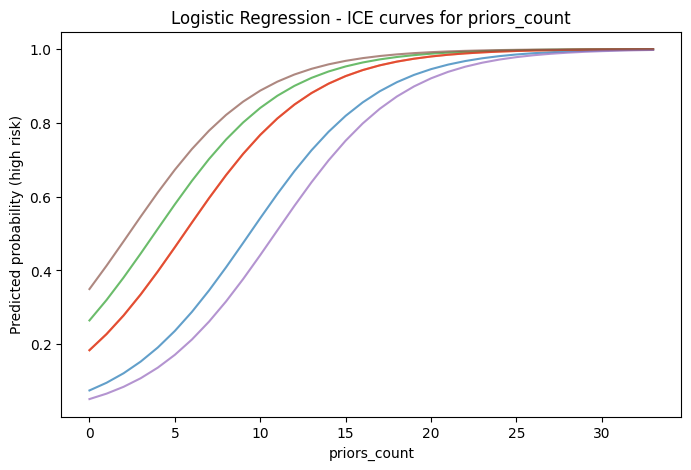

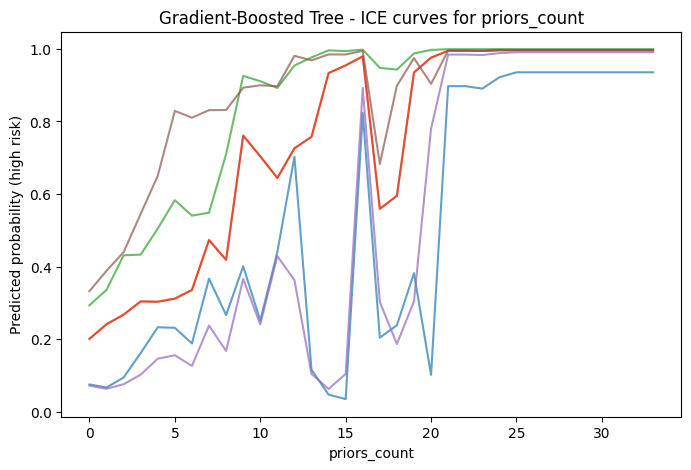


Global Sensitivity Index (priors_count)
     feature  sensitivity_index  min_mean_score  max_mean_score  range_mean_score                 model
priors_count           0.048791        0.287583        0.999167          0.711584   Logistic Regression
priors_count           0.041158        0.282523        0.980187          0.697664 Gradient-Boosted Tree


In [13]:
# Robustness: stress scenarios on priors_count

# Run the stress sweep separately for each model
for name, model in models.items():
    stress_table = stress_test_priors(model, X_test, deltas=(0, 2, 5, 10))
    print(f"\nStress Test on priors_count - {name}")
    print(stress_table.round(4).to_string(index=False))

# ICE-style sensitivity plots for priors_count
# Sweep the feature across its full integer range observed in test
priors_grid = np.arange(
    int(X_test["priors_count"].min()),
    int(X_test["priors_count"].max()) + 1
)

# One ICE plot per model so the curves can be compared visually
plot_ice_numeric(
    lr_pipeline,
    X_test,
    feature_col="priors_count",
    values=priors_grid,
    n_instances=6,
    random_state=42,
    title="Logistic Regression - ICE curves for priors_count"
)

plot_ice_numeric(
    gbt_pipeline,
    X_test,
    feature_col="priors_count",
    values=priors_grid,
    n_instances=6,
    random_state=42,
    title="Gradient-Boosted Tree - ICE curves for priors_count"
)

# Global sensitivity index for priors_count
# Variance of population-mean prediction as the feature is swept over the grid
lr_sens = global_sensitivity_index(lr_pipeline, X_test, "priors_count", priors_grid)
gbt_sens = global_sensitivity_index(gbt_pipeline, X_test, "priors_count", priors_grid)

# Stack both rows into one comparison table
sensitivity_table = pd.concat([
    lr_sens.assign(model="Logistic Regression"),
    gbt_sens.assign(model="Gradient-Boosted Tree"),
], ignore_index=True)

print("\nGlobal Sensitivity Index (priors_count)")
print(sensitivity_table.round(6).to_string(index=False))

### Interpretation

The stress sweep on `priors_count` shows both models responding strongly to the perturbation.

For logistic regression, mean predicted probability moves from 0.4476 at baseline to 0.5372 at +2, 0.6683 at +5, and 0.8435 at +10. Share predicted high risk moves from 0.4227 to 0.5368 to 0.7409 to 0.9247 across the same deltas. The gradient boosted tree follows the same trajectory: mean probability 0.4479 to 0.5641 to 0.7070 to 0.8267, and high-risk share 0.4089 to 0.5514 to 0.7328 to 0.8794. The aggregate response curves of the two models are very close.

The ICE plots show where the two models diverge at the individual level. The LR curves are smooth, monotonic, and roughly parallel across cases: every individual's predicted probability rises at a similar rate as priors increase. The GBT curves are jagged, with sharp jumps at some prior counts and flat plateaus at others, and the pattern is not consistent across individuals. The aggregate stress numbers hide this, but the per-case behavior is structurally different between the two models.

The global sensitivity index quantifies the same picture: 0.0488 for LR, 0.0412 for GBT, with mean-prediction ranges of 0.7116 (LR) and 0.6977 (GBT) across the swept grid. The two indices are close, even though the curve shapes are very different, which illustrates a methodological point. A single sensitivity scalar averages over individuals, so it cannot reveal the heterogeneity that ICE shows directly. Both views are needed.

### Audit Takeaway

Document `priors_count` in the Model Risk Management file as a high-leverage feature. The MRM entry must include three things: a substantive business justification for using it in this prediction task, the sensitivity-index value, and the qualitative description of how the per-case response differs between the two model families.

Prefer the logistic regression for documentability rather than for lower sensitivity. Its V_j is actually slightly higher than the GBT's, but its monotonic, parallel response is straightforward to describe in a model card and to defend on individual cases. The GBT's jagged ICE curves mean that explaining why two similar applicants received very different score changes for the same +1 in priors becomes a case-by-case exercise.

## Part E: Slice-based evaluation

In [14]:
# Robustness: slice-based evaluation
# Demographic + structural slices to inspect for performance gaps
slice_features = ["race_factor", "gender_factor", "age_factor", "crime_factor"]

for name, model in models.items():
    # One slice table per feature, then concatenate them for the model
    slice_tables = []
    for col in slice_features:
        slice_tables.append(slice_metrics(model, X_test, y_test, group_col=col))

    slice_eval = pd.concat(slice_tables, ignore_index=True)
    # Sort: group by feature, then by slice size (largest first) for readability
    slice_eval = slice_eval.sort_values(["slice_feature", "n"], ascending=[True, False])

    print(f"\nSlice-Based Evaluation - {name}")
    print(slice_eval.round(4).to_string(index=False))


Slice-Based Evaluation - Logistic Regression
slice_feature      slice_value    n  accuracy    auc  brier    fpr    fnr  positive_rate_pred  mean_score
   age_factor          25 - 45  695    0.7583 0.8326 0.1625 0.1658 0.3366              0.3871      0.4611
   age_factor  Greater than 45  272    0.8272 0.8492 0.1307 0.0498 0.5211              0.1618      0.2300
   age_factor     Less than 25  268    0.6604 0.7175 0.2023 0.6633 0.1529              0.7799      0.6338
 crime_factor                F  785    0.7376 0.8222 0.1721 0.2737 0.2524              0.5248      0.5137
 crime_factor                M  450    0.7778 0.8156 0.1503 0.1203 0.4627              0.2444      0.3324
gender_factor             Male 1000    0.7620 0.8448 0.1589 0.2135 0.2677              0.4480      0.4636
gender_factor           Female  235    0.7106 0.7832 0.1865 0.1606 0.4694              0.3149      0.3797
  race_factor African-American  634    0.7366 0.8195 0.1719 0.3870 0.1769              0.6435      0.5880


### Interpretation

Aggregate test performance from Part B looks acceptable for both models, but the slice tables show disparities the average hides.

**Race.** Under LR, the African-American slice has a 0.387 false positive rate against 0.109 for the Caucasian slice, about 3.5x higher. The false negative rates run in the opposite direction: 0.177 for African-American against 0.5625 for Caucasian. Positive prediction rates split 0.6435 vs 0.2112; mean predicted scores split 0.5880 vs 0.3168. The GBT shows the same qualitative pattern at similar magnitudes: 0.360 vs 0.099 on FPR, 0.244 vs 0.477 on FNR, 0.5931 vs 0.2306 on positive prediction rate. AUC values are close on the two main race slices (0.82 vs 0.79 under LR), so the model is not less discriminating on one slice; it is calibrated differently in a way that produces opposite error patterns. This is the empirical face of the Impossibility Theorem from Lecture 03: when base rates differ across groups, equal calibration and equal error rates cannot both hold. The structural tradeoff is a value choice.

**Age.** The under-25 slice carries the weakest performance on every axis. LR accuracy drops to 0.6604 against 0.8272 on over-45, AUC drops to 0.7175, and FPR climbs to 0.6633, meaning roughly two-thirds of under-25 defendants who do not re-offend are still flagged high risk. The over-45 slice has the inverse failure: low FPR (0.0498) but a 0.5211 false negative rate. The GBT pattern is the same in shape.

**Gender.** Smaller sample (n=235 female), smaller absolute disparities. Female accuracy and AUC are lower under both models. Female FNR under LR is 0.469 against male FNR of 0.268.

**Charge degree.** Felony cases get pushed toward high risk much more aggressively than misdemeanors. Positive prediction rate is 0.5248 vs 0.2444 under LR. Some of this is structurally expected, but the differential error allocation across charge categories still has to be documented.

**Small slices.** The Asian (n=8) and Native American (n=2) rows are not statistically meaningful. AUC of 1.000 on two cases is a sample-size artifact, not a finding.

The qualitative pattern is the same on the LR and the GBT. Substituting one classifier for the other does not move the disparity.

### Audit Takeaway

Stand up subgroup-stratified monitoring for race, age, and gender as a deployment requirement. The specific operational signals to track are the FPR/FNR pair for each slice, the positive prediction rate, and the mean score, against the reference values measured here. A 5% population slice carrying disproportionate false-positive volume meets the lecture's red-flag threshold and must be escalated, not footnoted.

Treat the under-25 slice as the leading candidate for threshold review. Its FPR of 0.66 under LR is the largest disparate error in the table and the most actionable on a per-deployment basis: thresholds can be set per slice or the model can be re-fit with a constraint that targets this error specifically.

Suppress the Asian and Native American rows from any version of this output that goes to a non-technical audience. Statistics on n = 8 and n = 2 will be misread.

Most importantly, escalate the model-choice question above the engineering team. The qualitative disparity pattern is the same across LR and GBT, which means the responsible-ML decision here is not a classifier-substitution decision. It is a question about feature set, label definition, and whether a deployment in this domain is defensible at all on this data. That decision belongs with the governance committee, not with model selection.

## Optional summary table

In [15]:
# Compact summary
# Pull selected results from the per-section tables into one long-format frame
summary_rows = []

# Drift: one row per numeric feature
for _, row in input_drift_table.iterrows():
    summary_rows.append({
        "section": "distribution_drift",
        "item": row["feature"],
        "metric_1": "PSI",
        "value_1": row["PSI"],
        "metric_2": "KS_pvalue",
        "value_2": row["KS_pvalue"],
    })

# Drift: high-dimensional MMD score (single row, no second metric)
summary_rows.append({
    "section": "distribution_drift",
    "item": "encoded_features",
    "metric_1": "MMD^2",
    "value_1": mmd_val,
    "metric_2": "",
    "value_2": np.nan,
})

# Generalization: one row per model with AUC and accuracy gaps
for _, row in generalization_table.iterrows():
    summary_rows.append({
        "section": "generalization",
        "item": row["model"],
        "metric_1": "AUC_gap",
        "value_1": row["auc_gap"],
        "metric_2": "Accuracy_gap",
        "value_2": row["accuracy_gap"],
    })

# Sensitivity: one row per model with the sensitivity index
for _, row in sensitivity_table.iterrows():
    summary_rows.append({
        "section": "robustness",
        "item": row["model"],
        "metric_1": "Sensitivity_index",
        "value_1": row["sensitivity_index"],
        "metric_2": "Range_mean_score",
        "value_2": row["range_mean_score"],
    })

live_summary = pd.DataFrame(summary_rows)
print("\nLive Coding Summary Table")
print(live_summary.round(6).to_string(index=False))


Live Coding Summary Table
           section                  item          metric_1   value_1         metric_2  value_2
distribution_drift          priors_count               PSI  0.010355        KS_pvalue 0.211294
distribution_drift        two_year_recid               PSI  0.000820        KS_pvalue 0.986154
distribution_drift      encoded_features             MMD^2 -0.000272                       NaN
    generalization   Logistic Regression           AUC_gap -0.003694     Accuracy_gap 0.001672
    generalization Gradient-Boosted Tree           AUC_gap  0.024467     Accuracy_gap 0.024964
        robustness   Logistic Regression Sensitivity_index  0.048791 Range_mean_score 0.711584
        robustness Gradient-Boosted Tree Sensitivity_index  0.041158 Range_mean_score 0.697664
